In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pickle
import gzip
import json

In [2]:
navsim_logs_paths = Path("/workspace/navsim_workspace/dataset/navsim_logs/trainval").glob("*.pkl")

# Under the foolder
# CAM_B0  CAM_F0  CAM_L0  CAM_L1  CAM_L2  CAM_R0  CAM_R1  CAM_R2  MergedPointCloud
# CAM is jpg files, MergedPointCloud is pcd file
sensor_logs_paths = Path("/workspace/navsim_workspace/dataset/sensor_blobs/trainval").glob("*")



In [3]:
navsim_log_path = next(navsim_logs_paths)
with open(navsim_log_path, "rb") as f:
    navsim_log = pickle.load(f)

In [4]:
navsim_log[2]


{'token': 'ba05ed7178e45fc1',
 'frame_idx': 2,
 'timestamp': 1623259733099639,
 'log_name': '2021.06.09.11.54.15_veh-12_05543_05765',
 'log_token': '3d1b23153a1d5b60',
 'scene_name': 'log-0109-scene-0001',
 'scene_token': '16a2cdef257155d9',
 'map_location': 'us-nv-las-vegas-strip',
 'roadblock_ids': ['65668',
  '66237',
  '65724',
  '60251',
  '47577',
  '66296',
  '65686',
  '66799',
  '65685',
  '66720',
  '65640',
  '67001',
  '65650',
  '60291',
  '47701',
  '66764',
  '65645',
  '66727',
  '65674',
  '66684',
  '65692',
  '66846',
  '65732',
  '66943',
  '65647',
  '66662',
  '47513'],
 'vehicle_name': 'veh-12',
 'can_bus': array([ 6.64437751e+05,  3.99706689e+06,  6.20286100e+02,  7.13806917e-01,
         7.42457876e-03, -9.77152898e-03, -7.00235017e-01,  1.34346342e+00,
         2.16429183e-01, -1.33530800e-01,  4.83197466e+00, -9.56048661e-02,
        -9.05324370e-04, -8.03524499e-03,  8.97162603e-04,  9.13880564e-03,
         0.00000000e+00,  0.00000000e+00]),
 'lidar_path': 

In [5]:
# transfuser_feature.gz  transfuser_target.gza
base_cache_dir = Path("/workspace/navsim_workspace/exp/training_cache/")
transfuser_feature_paths = base_cache_dir.rglob("transfuser_feature*.gz")
transfuser_target_paths = base_cache_dir.rglob("transfuser_target*.gz")

In [6]:
transfuser_feature_path = sorted(list(transfuser_feature_paths))[0]
with gzip.open(transfuser_feature_path, 'rb') as f:
    # Read the entire file content
    transfuser_feature = pickle.load(f)
# show all the files info
print(f"transfuser_feature keys: {transfuser_feature.keys()}")
print(f"{transfuser_feature['camera_feature'].shape=}")
print(f"{transfuser_feature['lidar_feature'].shape=}")
print(f"{transfuser_feature['status_feature'].shape=}")

transfuser_feature keys: dict_keys(['camera_feature', 'lidar_feature', 'status_feature'])
transfuser_feature['camera_feature'].shape=torch.Size([3, 256, 1024])
transfuser_feature['lidar_feature'].shape=torch.Size([1, 256, 256])
transfuser_feature['status_feature'].shape=torch.Size([8])


In [7]:
transfuser_target_path = sorted(list(transfuser_target_paths))[0]
with gzip.open(transfuser_target_path, 'rb') as f:
    transfuser_target = pickle.load(f)
print(f"transfuser_target keys: {transfuser_target.keys()}")
for key, value in transfuser_target.items():
    if hasattr(value, 'shape'):
        print(f"{key}: {value.shape}")
    else:
        print(f"{key}: {type(value)}")

transfuser_target keys: dict_keys(['trajectory', 'agent_states', 'agent_labels', 'bev_semantic_map'])
trajectory: torch.Size([8, 3])
agent_states: torch.Size([30, 5])
agent_labels: torch.Size([30])
bev_semantic_map: torch.Size([128, 256])


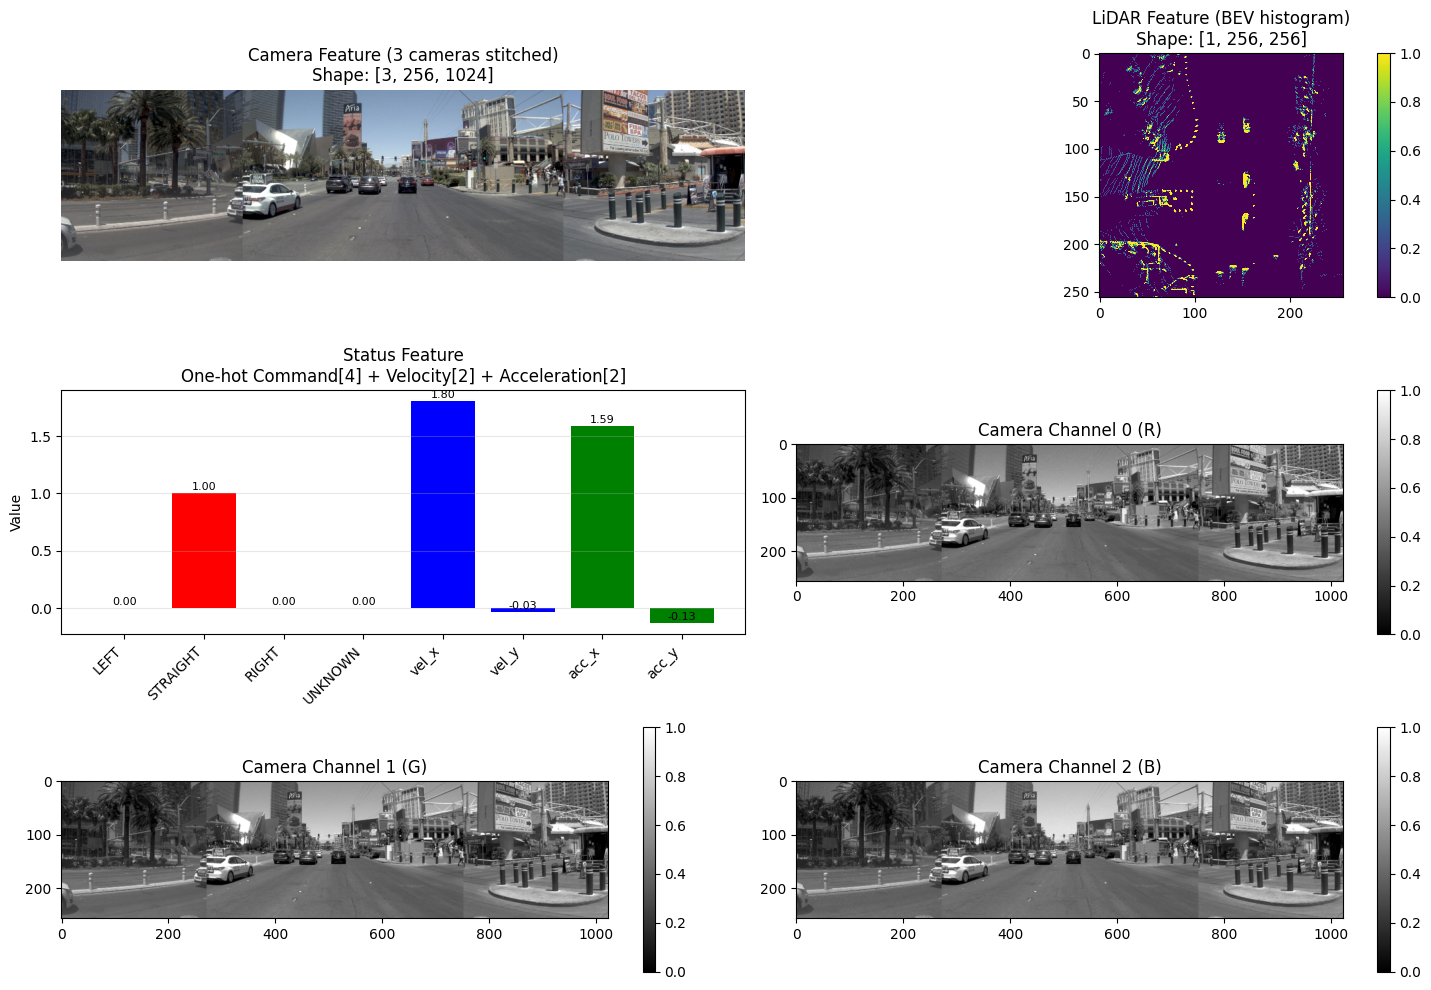


Feature Statistics:
Camera - min: 0.000, max: 1.000, mean: 0.408
LiDAR - min: 0.000, max: 1.000, mean: 0.043
Status - values: [ 0.          1.          0.          0.          1.8030407  -0.03375518
  1.5873523  -0.13237587]

Driving Command (one-hot): [0. 1. 0. 0.]
Active command: STRAIGHT

Velocity (x, y): (1.80, -0.03) m/s
Acceleration (x, y): (1.59, -0.13) m/s²


In [8]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def visualize_transfuser_features(features, figsize=(15, 10)):
    """
    Visualize transfuser features including camera, lidar, and status features.
    
    Args:
        features: Dictionary containing 'camera_feature', 'lidar_feature', 'status_feature'
        figsize: Figure size for the plot
    """
    fig = plt.figure(figsize=figsize)
    
    # 1. Visualize Camera Feature
    # Camera feature shape: [3, 256, 1024] - 3 RGB channels
    camera_feat = features['camera_feature']
    if isinstance(camera_feat, torch.Tensor):
        camera_feat = camera_feat.numpy()
    
    # Transpose from CHW to HWC for visualization
    camera_img = np.transpose(camera_feat, (1, 2, 0))
    
    # Normalize to [0, 1] range if needed
    if camera_img.max() > 1.0:
        camera_img = (camera_img - camera_img.min()) / (camera_img.max() - camera_img.min())
    
    plt.subplot(3, 2, 1)
    plt.imshow(camera_img)
    plt.title('Camera Feature (3 cameras stitched)\nShape: [3, 256, 1024]')
    plt.axis('off')
    
    # 2. Visualize LiDAR Feature
    # LiDAR feature shape: [1, 256, 256] - single channel histogram
    lidar_feat = features['lidar_feature']
    if isinstance(lidar_feat, torch.Tensor):
        lidar_feat = lidar_feat.numpy()
    
    # Remove channel dimension
    lidar_img = lidar_feat.squeeze(0)
    
    plt.subplot(3, 2, 2)
    plt.imshow(lidar_img, cmap='viridis', interpolation='nearest')
    plt.title('LiDAR Feature (BEV histogram)\nShape: [1, 256, 256]')
    plt.colorbar()
    
    # 3. Visualize Status Feature
    # Status feature shape: [8] - one-hot driving_command[4] + velocity[2] + acceleration[2]
    status_feat = features['status_feature']
    if isinstance(status_feat, torch.Tensor):
        status_feat = status_feat.numpy()
    
    # Based on the data, driving_command is already one-hot encoded:
    # [LEFT, STRAIGHT, RIGHT, UNKNOWN] + [vel_x, vel_y] + [acc_x, acc_y]
    
    plt.subplot(3, 2, 3)
    labels = ['LEFT', 'STRAIGHT', 'RIGHT', 'UNKNOWN', 'vel_x', 'vel_y', 'acc_x', 'acc_y']
    colors = ['red', 'red', 'red', 'red', 'blue', 'blue', 'green', 'green']
    bars = plt.bar(range(8), status_feat, color=colors)
    plt.xticks(range(8), labels, rotation=45, ha='right')
    plt.ylabel('Value')
    plt.title('Status Feature\nOne-hot Command[4] + Velocity[2] + Acceleration[2]')
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, status_feat)):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    
    # 4. Show RGB channels separately
    for i in range(3):
        plt.subplot(3, 2, 4 + i)
        channel = camera_feat[i]
        plt.imshow(channel, cmap='gray')
        plt.title(f'Camera Channel {i} ({"RGB"[i]})')
        plt.colorbar()
    
    plt.tight_layout()
    plt.show()
    
    # Print feature statistics
    print("\nFeature Statistics:")
    print(f"Camera - min: {camera_feat.min():.3f}, max: {camera_feat.max():.3f}, mean: {camera_feat.mean():.3f}")
    print(f"LiDAR - min: {lidar_feat.min():.3f}, max: {lidar_feat.max():.3f}, mean: {lidar_feat.mean():.3f}")
    print(f"Status - values: {status_feat}")
    
    # Interpret driving command (one-hot encoded)
    driving_cmd = status_feat[:4]
    print(f"\nDriving Command (one-hot): {driving_cmd}")
    
    # According to driving_command_analysis.md:
    # 0 = LEFT (turns, lane changes, sharp curves)
    # 1 = STRAIGHT
    # 2 = RIGHT (turns, lane changes, sharp curves)
    # 3 = UNKNOWN (can be filtered)
    cmd_names = ['LEFT', 'STRAIGHT', 'RIGHT', 'UNKNOWN']
    active_cmd_idx = np.argmax(driving_cmd)
    if driving_cmd[active_cmd_idx] == 1.0:
        print(f"Active command: {cmd_names[active_cmd_idx]}")
    
    print(f"\nVelocity (x, y): ({status_feat[4]:.2f}, {status_feat[5]:.2f}) m/s")
    print(f"Acceleration (x, y): ({status_feat[6]:.2f}, {status_feat[7]:.2f}) m/s²")

# Call the visualization function
visualize_transfuser_features(transfuser_feature)

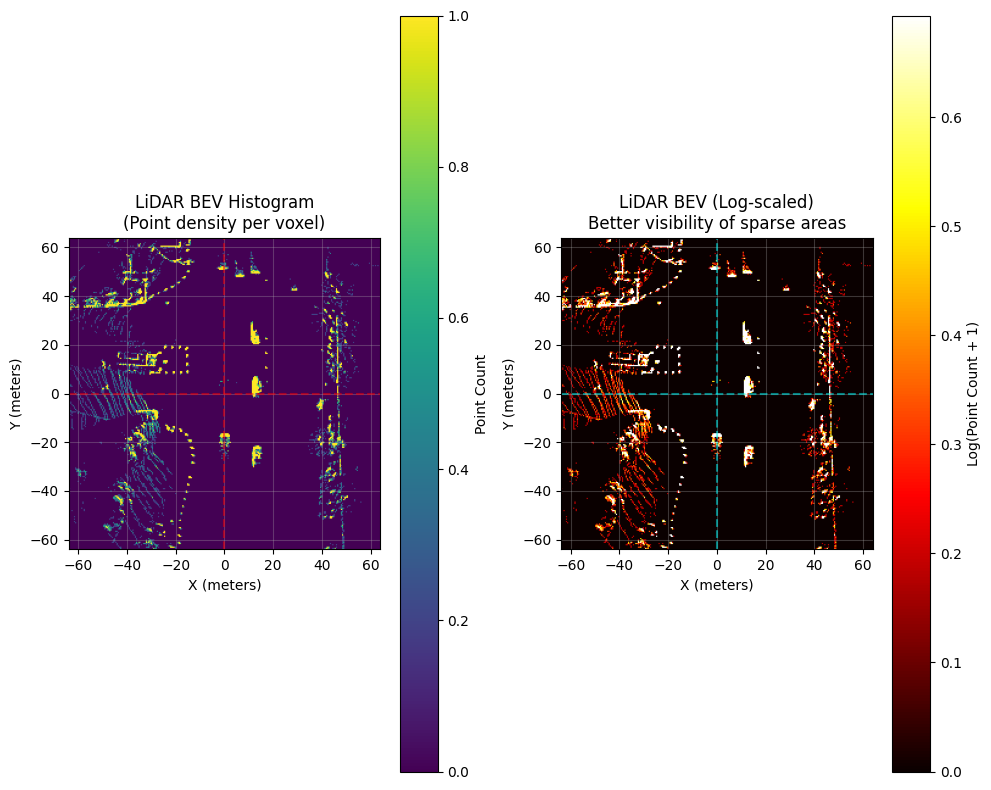

LiDAR BEV Statistics:
  Shape: (256, 256)
  Spatial coverage: 128.0m x 128.0m
  Voxel size: 0.5m
  Non-zero voxels: 5698 / 65536 (8.7%)
  Max points per voxel: 1
  Mean points (non-zero voxels): 0.49


In [9]:
def visualize_lidar_bev(lidar_feature, voxel_size=0.5, figsize=(10, 8)):
    """
    Visualize LiDAR BEV (Bird's Eye View) histogram with proper scaling.
    
    Args:
        lidar_feature: LiDAR feature tensor/array of shape [1, 256, 256]
        voxel_size: Size of each voxel in meters (default 0.5m based on TransFuser)
        figsize: Figure size
    """
    lidar_feat = lidar_feature
    if isinstance(lidar_feat, torch.Tensor):
        lidar_feat = lidar_feat.numpy()
    
    # Remove channel dimension
    lidar_bev = lidar_feat.squeeze(0)
    
    # Calculate the spatial extent
    # TransFuser uses 256x256 grid with 0.5m voxels = 128m x 128m area
    extent_m = 256 * voxel_size / 2  # 64m in each direction
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Original BEV visualization
    im1 = ax1.imshow(lidar_bev, cmap='viridis', origin='lower',
                     extent=[-extent_m, extent_m, -extent_m, extent_m])
    ax1.set_xlabel('X (meters)')
    ax1.set_ylabel('Y (meters)')
    ax1.set_title('LiDAR BEV Histogram\n(Point density per voxel)')
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax1.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    plt.colorbar(im1, ax=ax1, label='Point Count')
    
    # Log-scaled visualization for better contrast
    lidar_log = np.log1p(lidar_bev)  # log(1 + x) to handle zeros
    im2 = ax2.imshow(lidar_log, cmap='hot', origin='lower',
                     extent=[-extent_m, extent_m, -extent_m, extent_m])
    ax2.set_xlabel('X (meters)')
    ax2.set_ylabel('Y (meters)')
    ax2.set_title('LiDAR BEV (Log-scaled)\nBetter visibility of sparse areas')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='cyan', linestyle='--', alpha=0.5)
    ax2.axvline(x=0, color='cyan', linestyle='--', alpha=0.5)
    plt.colorbar(im2, ax=ax2, label='Log(Point Count + 1)')
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print(f"LiDAR BEV Statistics:")
    print(f"  Shape: {lidar_bev.shape}")
    print(f"  Spatial coverage: {2*extent_m:.1f}m x {2*extent_m:.1f}m")
    print(f"  Voxel size: {voxel_size}m")
    print(f"  Non-zero voxels: {np.count_nonzero(lidar_bev)} / {lidar_bev.size} ({100*np.count_nonzero(lidar_bev)/lidar_bev.size:.1f}%)")
    print(f"  Max points per voxel: {lidar_bev.max():.0f}")
    print(f"  Mean points (non-zero voxels): {lidar_bev[lidar_bev > 0].mean():.2f}")

# Visualize the LiDAR feature in detail
visualize_lidar_bev(transfuser_feature['lidar_feature'])

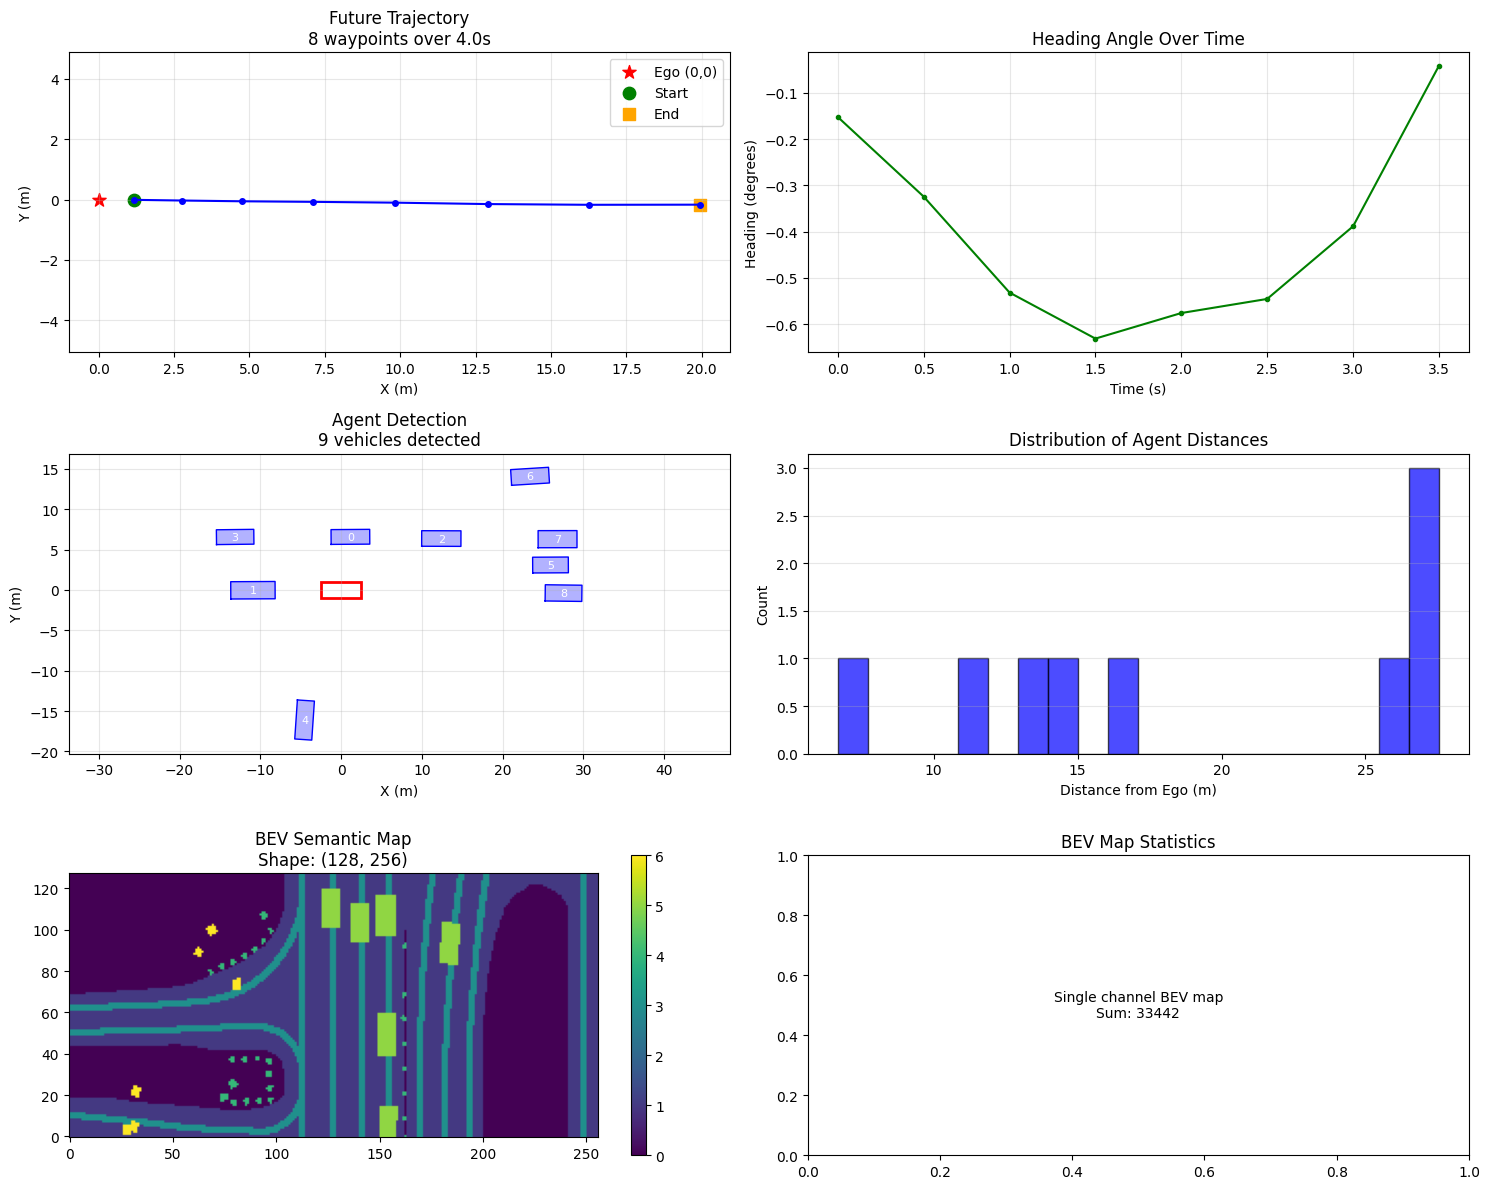


Target Statistics:
Trajectory: 8 waypoints, total distance: 18.76m
Agent States: 30 slots, 9 valid detections
BEV Semantic Map: (128, 256)

Closest agent: 6.68m
Farthest agent: 27.55m


In [10]:
def visualize_transfuser_targets(targets, figsize=(15, 12)):
    """
    Visualize transfuser targets including trajectory, agent states, and BEV semantic map.
    
    Args:
        targets: Dictionary containing 'trajectory', 'agent_states', 'agent_labels', 'bev_semantic_map'
        figsize: Figure size for the plot
    """
    fig = plt.figure(figsize=figsize)
    
    # 1. Visualize Trajectory
    trajectory = targets['trajectory']
    if isinstance(trajectory, torch.Tensor):
        trajectory = trajectory.numpy()
    
    plt.subplot(3, 2, 1)
    # Plot trajectory in 2D (x, y)
    plt.plot(trajectory[:, 0], trajectory[:, 1], 'b.-', markersize=8)
    plt.scatter(0, 0, c='red', s=100, marker='*', label='Ego (0,0)')
    plt.scatter(trajectory[0, 0], trajectory[0, 1], c='green', s=80, marker='o', label='Start')
    plt.scatter(trajectory[-1, 0], trajectory[-1, 1], c='orange', s=80, marker='s', label='End')
    plt.xlabel('X (m)')
    plt.ylabel('Y (m)')
    plt.title(f'Future Trajectory\n{trajectory.shape[0]} waypoints over {trajectory.shape[0]*0.5:.1f}s')
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.legend()
    
    # 2. Plot heading over time
    plt.subplot(3, 2, 2)
    time_steps = np.arange(len(trajectory)) * 0.5  # 0.5s intervals
    plt.plot(time_steps, np.rad2deg(trajectory[:, 2]), 'g.-')
    plt.xlabel('Time (s)')
    plt.ylabel('Heading (degrees)')
    plt.title('Heading Angle Over Time')
    plt.grid(True, alpha=0.3)
    
    # 3. Visualize Agent States and Labels
    agent_states = targets['agent_states']
    agent_labels = targets['agent_labels']
    if isinstance(agent_states, torch.Tensor):
        agent_states = agent_states.numpy()
    if isinstance(agent_labels, torch.Tensor):
        agent_labels = agent_labels.numpy()
    
    # Filter valid agents (where label is True)
    valid_agents = agent_states[agent_labels]
    
    plt.subplot(3, 2, 3)
    # Plot agent bounding boxes
    ax = plt.gca()
    
    # Plot ego vehicle at origin
    ego_rect = plt.Rectangle((-2.5, -1), 5, 2, 
                           fill=False, edgecolor='red', linewidth=2, label='Ego')
    ax.add_patch(ego_rect)
    
    # Plot other agents - simplified version without rotation transform
    for i, agent in enumerate(valid_agents):
        x, y, heading, length, width = agent
        
        # Draw simple oriented box
        corners = np.array([
            [-length/2, -width/2],
            [length/2, -width/2],
            [length/2, width/2],
            [-length/2, width/2],
            [-length/2, -width/2]
        ])
        
        # Rotate corners
        cos_h = np.cos(heading)
        sin_h = np.sin(heading)
        rotated_corners = np.zeros_like(corners)
        rotated_corners[:, 0] = corners[:, 0] * cos_h - corners[:, 1] * sin_h + x
        rotated_corners[:, 1] = corners[:, 0] * sin_h + corners[:, 1] * cos_h + y
        
        # Plot the box
        plt.plot(rotated_corners[:, 0], rotated_corners[:, 1], 'b-', linewidth=1)
        plt.fill(rotated_corners[:, 0], rotated_corners[:, 1], 'blue', alpha=0.3)
        
        # Add agent number
        plt.text(x, y, str(i), ha='center', va='center', color='white', fontsize=8)
    
    plt.xlim(-64, 64)
    plt.ylim(-64, 64)
    plt.xlabel('X (m)')
    plt.ylabel('Y (m)')
    plt.title(f'Agent Detection\n{len(valid_agents)} vehicles detected')
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    
    # 4. Agent states histogram
    plt.subplot(3, 2, 4)
    if len(valid_agents) > 0:
        distances = np.sqrt(valid_agents[:, 0]**2 + valid_agents[:, 1]**2)
        plt.hist(distances, bins=20, alpha=0.7, color='blue', edgecolor='black')
        plt.xlabel('Distance from Ego (m)')
        plt.ylabel('Count')
        plt.title('Distribution of Agent Distances')
        plt.grid(axis='y', alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'No agents detected', ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('Distribution of Agent Distances')
    
    # 5. Visualize BEV Semantic Map
    bev_map = targets['bev_semantic_map']
    if isinstance(bev_map, torch.Tensor):
        bev_map = bev_map.numpy()
    
    # BEV semantic map has 7 classes based on the code
    class_names = ['Background', 'Road', 'Walkway', 'Vehicles', 'Lane Divider', 
                   'Carpark', 'Pedestrian Crossing']
    
    plt.subplot(3, 2, 5)
    
    # Check the shape of bev_map
    if len(bev_map.shape) == 3:  # Has channel dimension
        # Show RGB visualization by combining first 3 channels
        if bev_map.shape[0] >= 3:
            bev_rgb = bev_map[:3].transpose(1, 2, 0)
            # Normalize for visualization
            bev_rgb = (bev_rgb - bev_rgb.min()) / (bev_rgb.max() - bev_rgb.min() + 1e-8)
            plt.imshow(bev_rgb, origin='lower')
            plt.title(f'BEV Semantic Map (RGB channels)\nShape: {bev_map.shape}')
        else:
            plt.imshow(bev_map[0], cmap='viridis', origin='lower')
            plt.title(f'BEV Semantic Map (Channel 0)\nShape: {bev_map.shape}')
    elif len(bev_map.shape) == 2:  # Single channel
        plt.imshow(bev_map, cmap='viridis', origin='lower')
        plt.title(f'BEV Semantic Map\nShape: {bev_map.shape}')
    else:
        plt.text(0.5, 0.5, f'Unexpected BEV map shape: {bev_map.shape}', 
                ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('BEV Semantic Map')
    
    plt.colorbar()
    
    # 6. Show individual semantic channels
    plt.subplot(3, 2, 6)
    
    if len(bev_map.shape) == 3:
        # Calculate which channels have content
        channel_sums = [bev_map[i].sum() for i in range(bev_map.shape[0])]
        active_channels = [(i, class_names[i] if i < len(class_names) else f'Class {i}', channel_sums[i]) 
                           for i in range(len(channel_sums)) if channel_sums[i] > 0]
        
        if active_channels:
            channels, names, sums = zip(*active_channels)
            plt.bar(range(len(active_channels)), sums)
            plt.xticks(range(len(active_channels)), names, rotation=45, ha='right')
            plt.ylabel('Total Activation')
            plt.title('Semantic Class Activations')
            plt.grid(axis='y', alpha=0.3)
        else:
            plt.text(0.5, 0.5, 'No active semantic channels', ha='center', va='center', 
                    transform=plt.gca().transAxes)
    else:
        plt.text(0.5, 0.5, f'Single channel BEV map\nSum: {bev_map.sum():.0f}', 
                ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('BEV Map Statistics')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\nTarget Statistics:")
    print(f"Trajectory: {trajectory.shape[0]} waypoints, total distance: {np.sum(np.linalg.norm(np.diff(trajectory[:, :2], axis=0), axis=1)):.2f}m")
    print(f"Agent States: {agent_states.shape[0]} slots, {len(valid_agents)} valid detections")
    print(f"BEV Semantic Map: {bev_map.shape}")
    
    if len(valid_agents) > 0:
        print(f"\nClosest agent: {np.min(np.sqrt(valid_agents[:, 0]**2 + valid_agents[:, 1]**2)):.2f}m")
        print(f"Farthest agent: {np.max(np.sqrt(valid_agents[:, 0]**2 + valid_agents[:, 1]**2)):.2f}m")

# Visualize the targets
visualize_transfuser_targets(transfuser_target)

In [11]:
# First, let's check what we have in the targets
print("Checking target shapes:")
for key, value in transfuser_target.items():
    if hasattr(value, 'shape'):
        print(f"{key}: {value.shape}")
    else:
        print(f"{key}: {type(value)}")

Checking target shapes:
trajectory: torch.Size([8, 3])
agent_states: torch.Size([30, 5])
agent_labels: torch.Size([30])
bev_semantic_map: torch.Size([128, 256])


BEV semantic map info:
  Shape: torch.Size([128, 256])
  Type: <class 'torch.Tensor'>
  Dtype: torch.float32
BEV map shape: (128, 256)
BEV map dtype: float32


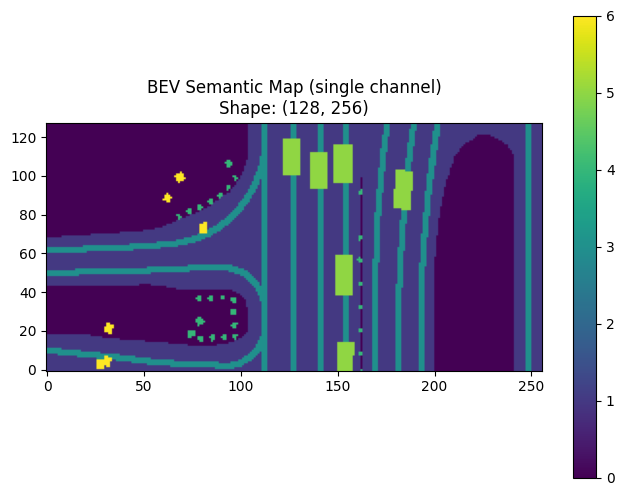

In [12]:
def visualize_bev_semantic_channels(bev_map, figsize=(15, 10)):
    """
    Visualize each semantic channel of the BEV map individually.
    
    Args:
        bev_map: BEV semantic map tensor/array of shape [7, H, W]
        figsize: Figure size
    """
    if isinstance(bev_map, torch.Tensor):
        bev_map = bev_map.numpy()
    
    print(f"BEV map shape: {bev_map.shape}")
    print(f"BEV map dtype: {bev_map.dtype}")
    
    # Handle different shapes
    if len(bev_map.shape) == 1:
        # If 1D, try to reshape to square
        size = int(np.sqrt(bev_map.shape[0]))
        if size * size == bev_map.shape[0]:
            print(f"Reshaping 1D array ({bev_map.shape[0]}) to 2D ({size}x{size})")
            bev_map = bev_map.reshape(size, size)
            # Treat as single channel
            plt.figure(figsize=(8, 6))
            plt.imshow(bev_map, cmap='viridis', origin='lower')
            plt.title(f'BEV Semantic Map (reshaped from 1D)\nShape: {bev_map.shape}')
            plt.colorbar()
            plt.show()
            return
        else:
            print(f"Cannot reshape 1D array of size {bev_map.shape[0]} to square")
            return
    
    elif len(bev_map.shape) == 2:
        # Single channel 2D map
        plt.figure(figsize=(8, 6))
        plt.imshow(bev_map, cmap='viridis', origin='lower')
        plt.title(f'BEV Semantic Map (single channel)\nShape: {bev_map.shape}')
        plt.colorbar()
        plt.show()
        return
    
    # Multi-channel case (3D)
    # Semantic classes from transfuser_features.py
    class_names = [
        'Background',      # 0
        'Road',           # 1  
        'Walkway',        # 2
        'Vehicles',       # 3
        'Lane Divider',   # 4
        'Carpark',        # 5
        'Ped Crossing'    # 6
    ]
    
    n_classes = bev_map.shape[0]
    n_cols = 3
    n_rows = (n_classes + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for i in range(n_classes):
        ax = axes[i]
        channel = bev_map[i]
        
        # Check if channel is 2D
        if len(channel.shape) != 2:
            ax.text(0.5, 0.5, f'Channel {i} has shape {channel.shape}', 
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'Invalid channel {i}')
            ax.axis('off')
            continue
        
        # Use different colormaps for different classes
        if i == 0:  # Background
            cmap = 'gray'
        elif i == 1:  # Road
            cmap = 'Blues'
        elif i == 2:  # Walkway
            cmap = 'Oranges'
        elif i == 3:  # Vehicles
            cmap = 'Reds'
        elif i == 4:  # Lane Divider
            cmap = 'Greens'
        elif i == 5:  # Carpark
            cmap = 'Purples'
        else:  # Pedestrian Crossing
            cmap = 'YlOrBr'
            
        im = ax.imshow(channel, cmap=cmap, origin='lower')
        
        # Add title with statistics
        title = f'{class_names[i] if i < len(class_names) else f"Class {i}"}'
        if channel.sum() > 0:
            title += f'\nMax: {channel.max():.2f}, Sum: {channel.sum():.0f}'
        else:
            title += '\n(Empty)'
            
        ax.set_title(title)
        ax.axis('off')
        
        # Add colorbar for non-empty channels
        if channel.sum() > 0:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    # Hide unused subplots
    for i in range(n_classes, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'BEV Semantic Map Channels\nShape: {bev_map.shape}', fontsize=14)
    plt.tight_layout()
    plt.show()

# First check the shape
if 'bev_semantic_map' in transfuser_target:
    print("BEV semantic map info:")
    bev = transfuser_target['bev_semantic_map']
    if hasattr(bev, 'shape'):
        print(f"  Shape: {bev.shape}")
        print(f"  Type: {type(bev)}")
        if hasattr(bev, 'dtype'):
            print(f"  Dtype: {bev.dtype}")
    
    # Visualize individual BEV channels
    visualize_bev_semantic_channels(transfuser_target['bev_semantic_map'])
else:
    print("No bev_semantic_map found in targets")

In [13]:
def load_and_visualize_sequence(cache_dir, log_name, start_token, num_frames=5):
    """
    Load and visualize a sequence of features from the cache.
    
    Args:
        cache_dir: Base cache directory
        log_name: Log folder name
        start_token: Starting token
        num_frames: Number of frames to visualize
    """
    # Find feature files
    log_path = cache_dir / log_name
    feature_files = sorted(log_path.glob("transfuser_feature_*.gz"))
    
    # Find the starting index
    start_idx = None
    for i, f in enumerate(feature_files):
        if start_token in f.name:
            start_idx = i
            break
    
    if start_idx is None:
        print(f"Token {start_token} not found")
        return
    
    # Load features
    features_list = []
    for i in range(start_idx, min(start_idx + num_frames, len(feature_files))):
        with gzip.open(feature_files[i], 'rb') as f:
            features_list.append(pickle.load(f))
    
    # Create visualization
    fig = plt.figure(figsize=(20, 4 * len(features_list)))
    
    for idx, features in enumerate(features_list):
        # Camera
        ax1 = plt.subplot(len(features_list), 4, idx * 4 + 1)
        camera_img = np.transpose(features['camera_feature'].numpy(), (1, 2, 0))
        if camera_img.max() > 1.0:
            camera_img = (camera_img - camera_img.min()) / (camera_img.max() - camera_img.min())
        ax1.imshow(camera_img)
        ax1.set_title(f'Frame {idx}: Camera')
        ax1.axis('off')
        
        # LiDAR
        ax2 = plt.subplot(len(features_list), 4, idx * 4 + 2)
        lidar_img = features['lidar_feature'].numpy().squeeze(0)
        ax2.imshow(np.log1p(lidar_img), cmap='hot', origin='lower')
        ax2.set_title(f'Frame {idx}: LiDAR (log)')
        ax2.axis('off')
        
        # Status
        ax3 = plt.subplot(len(features_list), 4, idx * 4 + 3)
        status = features['status_feature'].numpy()
        labels_short = ['vx', 'vy', 'ax', 'ay', 'stop', 'left', 'right', 'straight']
        colors = ['b', 'b', 'g', 'g', 'r', 'orange', 'orange', 'orange']
        ax3.bar(range(8), status, color=colors)
        ax3.set_xticks(range(8))
        ax3.set_xticklabels(labels_short, rotation=45)
        ax3.set_title(f'Frame {idx}: Status')
        ax3.grid(axis='y', alpha=0.3)
        
        # Driving command interpretation
        ax4 = plt.subplot(len(features_list), 4, idx * 4 + 4)
        cmd_idx = np.argmax(status[4:8])
        cmd_names = ['STOP', 'LEFT', 'RIGHT', 'STRAIGHT']
        ax4.text(0.5, 0.7, f'Command: {cmd_names[cmd_idx]}', 
                ha='center', va='center', fontsize=16, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue'))
        ax4.text(0.5, 0.3, f'Velocity: ({status[0]:.1f}, {status[1]:.1f}) m/s\nAccel: ({status[2]:.1f}, {status[3]:.1f}) m/s²', 
                ha='center', va='center', fontsize=12)
        ax4.set_xlim(0, 1)
        ax4.set_ylim(0, 1)
        ax4.axis('off')
    
    plt.tight_layout()
    plt.show()

# Example: Load a sequence (you'll need to adjust the path and token)
# load_and_visualize_sequence(base_cache_dir, "log_folder_name", "token_string", num_frames=3)